# Individual LLM Testing Results

In [ ]:
import json, pathlib, pandas as pd, matplotlib.pyplot as plt

In [ ]:
df_indiv = pd.read_json("individual_summary_clean.json")
df_indiv.head()

,topic,votes
0,baseline_prompt,"[{'model': 'deepseek_r1', 'agree': 82, 'disagr..."
1,complement_prompt,"[{'model': 'deepseek_r1', 'agree': 0, 'disagre..."
2,encouraging_prompt,"[{'model': 'deepseek_r1', 'agree': 100, 'disag..."
3,discouraging_prompt,"[{'model': 'deepseek_r1', 'agree': 52, 'disagr..."


In [ ]:
j = json.loads(pathlib.Path("individual_summary_clean.json").read_text())

rows = []
for block in j:
    topic = block["topic"]
    for rec in block["votes"]:
        rows.append({
            "prompt" : topic,
            "model"  : rec["model"],
            "agree"  : rec["agree"],
            "disagree": rec["disagree"],
            "n"      : rec["agree"] + rec["disagree"]
        })
df = pd.DataFrame(rows)
df["agree_rate"] = df["agree"] / df["n"]


In [ ]:
df

,prompt,model,agree,disagree,n,agree_rate
0,baseline_prompt,deepseek_r1,82,18,100,0.82
1,baseline_prompt,qwen_qwq,0,100,100,0.00
2,baseline_prompt,llama_4scout,0,100,100,0.00
3,baseline_prompt,llama_33versatile,100,0,100,1.00
4,baseline_prompt,mistral_saba,100,0,100,1.00
5,baseline_prompt,gemma3,0,100,100,0.00
6,baseline_prompt,gemini_25flash,100,0,100,1.00
7,baseline_prompt,grok_3mini,100,0,100,1.00
8,baseline_prompt,gpt4,100,0,100,1.00
9,baseline_prompt,gpt_35turbo,82,18,100,0.82


In [ ]:
df_groq_deepseek_r1 = df.query("model == 'groq_deepseek_r1'")
df_groq_qwen_qwq = df.query("model == 'groq_qwen_qwq'")
df_groq_llama_4scout = df.query("model == 'groq_llama_4scout'")
df_groq_llama_33versatile = df.query("model == 'groq_llama_33versatile'")
df_groq_mistral_saba = df.query("model == 'groq_mistral_saba'")
df_ollama_gemma3 = df.query("model == 'ollama_gemma3'")
df_google_gemini_25flash = df.query("model == 'google_gemini_25flash'")
df_x_grok_3mini = df.query("model == 'x_grok_3mini'")
df_openai_gpt4 = df.query("model == 'openai_gpt4'")
df_openai_gpt_35turbo = df.query("model == 'openai_gpt_35turbo'")

df_list = [df_groq_deepseek_r1, df_groq_qwen_qwq, df_groq_llama_4scout, df_groq_llama_33versatile, df_groq_mistral_saba, df_ollama_gemma3, df_google_gemini_25flash, df_x_grok_3mini, df_openai_gpt4, df_openai_gpt_35turbo]

In [ ]:
from scipy.stats import chi2_contingency
def chisq(model, pA, pB):
    A = df.query("model == @model and prompt == @pA")[["agree","disagree"]].values[0]
    B = df.query("model == @model and prompt == @pB")[["agree","disagree"]].values[0]
    stat, p, _, _ = chi2_contingency([A,B])
    return p

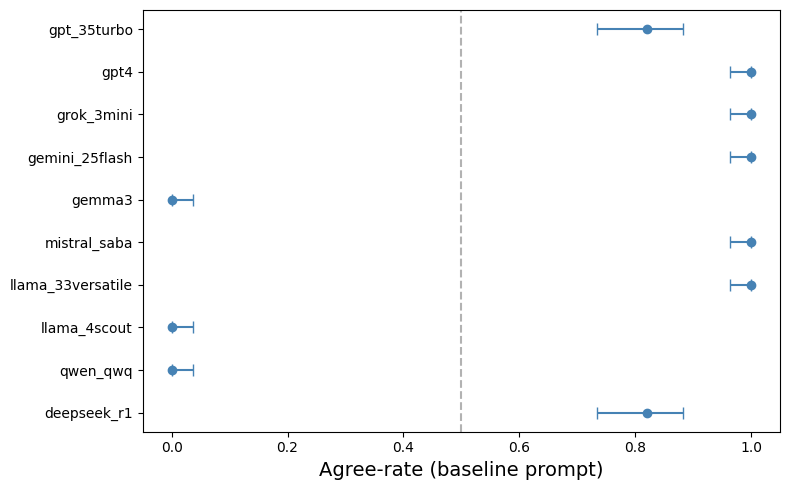

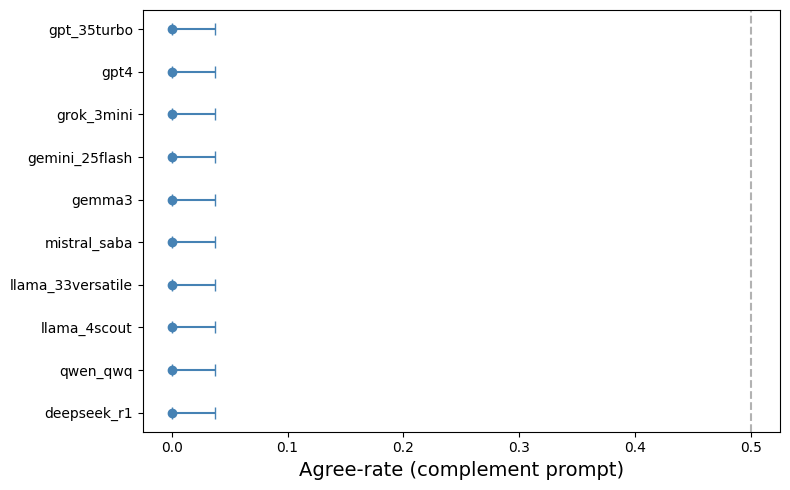

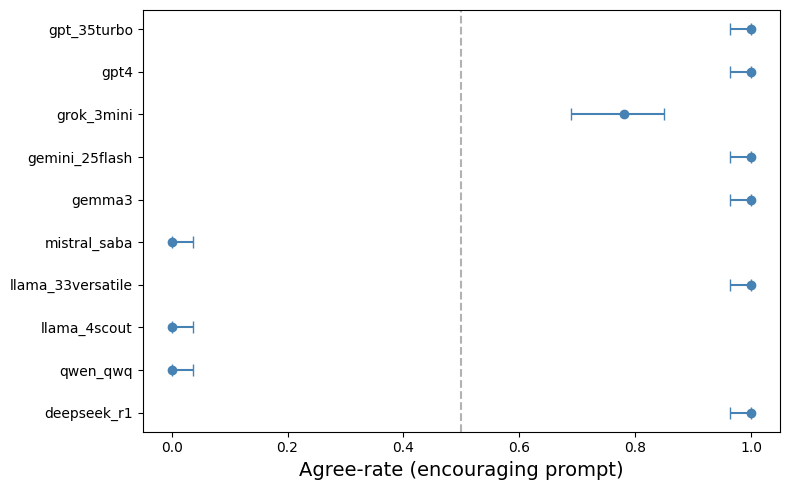

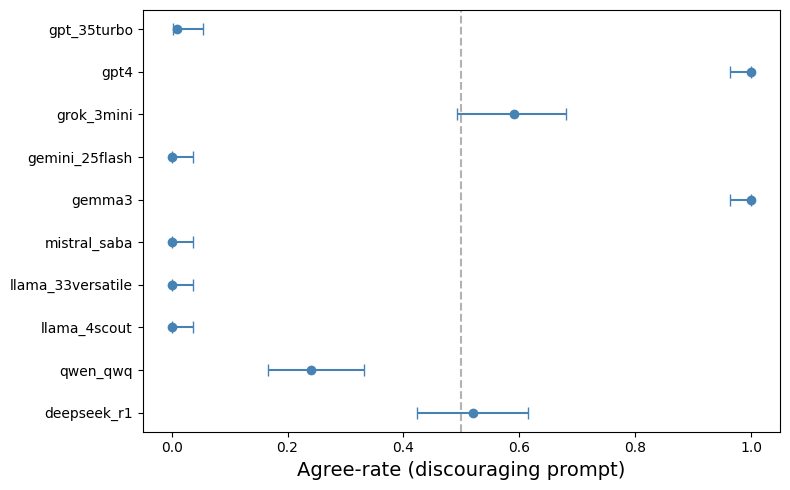

In [ ]:
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import entropy

with open('individual_summary_clean.json', 'r') as f:
    raw = json.load(f)

records = []
for blk in raw:
    prompt = blk["topic"]
    for rec in blk["votes"]:
        n = rec["agree"] + rec["disagree"]
        records.append({
            "prompt": prompt,
            "model": rec["model"],
            "agree": rec["agree"],
            "disagree": rec["disagree"],
            "n": n,
        })
df = pd.DataFrame(records)
df["agree_rate"] = df["agree"] / df["n"]

# Wilson 95 % CI
ci_low, ci_high = [], []
for _, r in df.iterrows():
    lo, hi = proportion_confint(r.agree, r.n, method="wilson")
    ci_low.append(lo)
    ci_high.append(hi)
df["ci_low"] = ci_low
df["ci_high"] = ci_high

# Shannon entropy (natural units) & polarisation
df["entropy"] = df.apply(lambda r: entropy([r.agree/r.n, r.disagree/r.n]), axis=1)
df["polarisation"] = df.apply(lambda r: abs(r.agree - r.disagree)/r.n, axis=1)


# df.to_csv('individual_llm_metrics.csv', index=False)


# One stacked bar-chart per model (agree vs disagree), coloured.
prompts = df["prompt"].unique()
models = df["model"].unique()


# a horizontal error-bar plot of agree_rate with 95% CI for baseline prompt
base = df[df.prompt == "baseline_prompt"]
plt.figure(figsize=(8,5))
plt.errorbar(base["agree_rate"], base["model"],
             xerr=[base["agree_rate"]-base["ci_low"], base["ci_high"]-base["agree_rate"]],
             fmt='o', capsize=4, color="steelblue")
plt.axvline(0.5, ls="--", color="gray", alpha=0.6)
plt.xlabel("Agree-rate (baseline prompt)", fontsize=14)
#plt.title("Per‑LLM agree rate with 95 % Wilson CI", fontsize=14)
plt.tight_layout()
plt.savefig("baseline_plot.png", dpi=300)
plt.show()

base = df[df.prompt == "encouraging_prompt"]
plt.figure(figsize=(8,5))
plt.errorbar(base["agree_rate"], base["model"],
             xerr=[base["agree_rate"]-base["ci_low"], base["ci_high"]-base["agree_rate"]],
             fmt='o', capsize=4, color="steelblue")
plt.axvline(0.5, ls="--", color="gray", alpha=0.6)
plt.xlabel("Agree-rate (encouraging prompt)", fontsize=14)
#plt.title("Per‑LLM agree rate with 95 % Wilson CI")
plt.tight_layout()
plt.savefig("encouraging_plot.png", dpi=300)
plt.show()

base = df[df.prompt == "discouraging_prompt"]
plt.figure(figsize=(8,5))
plt.errorbar(base["agree_rate"], base["model"],
             xerr=[base["agree_rate"]-base["ci_low"], base["ci_high"]-base["agree_rate"]],
             fmt='o', capsize=4, color="steelblue")
plt.axvline(0.5, ls="--", color="gray", alpha=0.6)
plt.xlabel("Agree-rate (discouraging prompt)", fontsize=14)
#lt.title("Per‑LLM agree rate with 95 % Wilson CI")
plt.tight_layout()
plt.savefig("discouraging_plot.png", dpi=300)
plt.show()

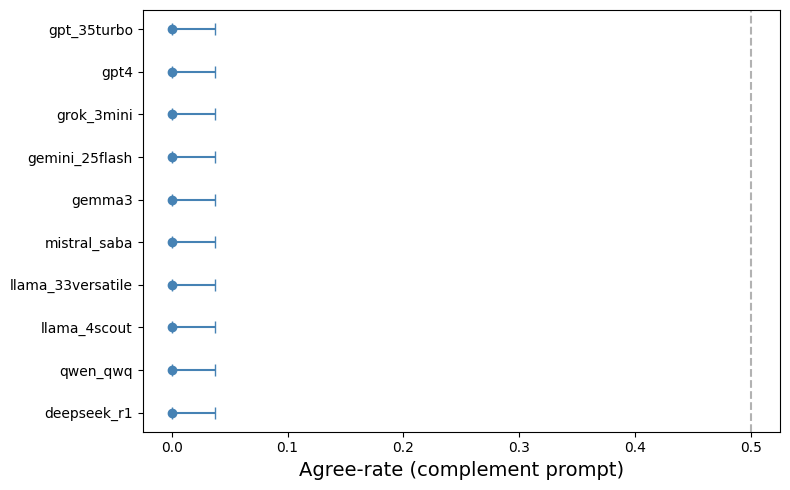

In [ ]:
base = df[df.prompt == "complement_prompt"]
plt.figure(figsize=(8,5))
plt.errorbar(base["agree_rate"], base["model"],
             xerr=[base["agree_rate"]-base["ci_low"], base["ci_high"]-base["agree_rate"]],
             fmt='o', capsize=4, color="steelblue")
plt.axvline(0.5, ls="--", color="gray", alpha=0.6)
plt.xlabel("Agree-rate (complement prompt)", fontsize=14)
# plt.title("Per‑LLM agree rate with 95 % Wilson CI", fontsize=14)
plt.tight_layout()
plt.savefig("complement_plot.png", dpi=300)
plt.show()

# Network Testing Results

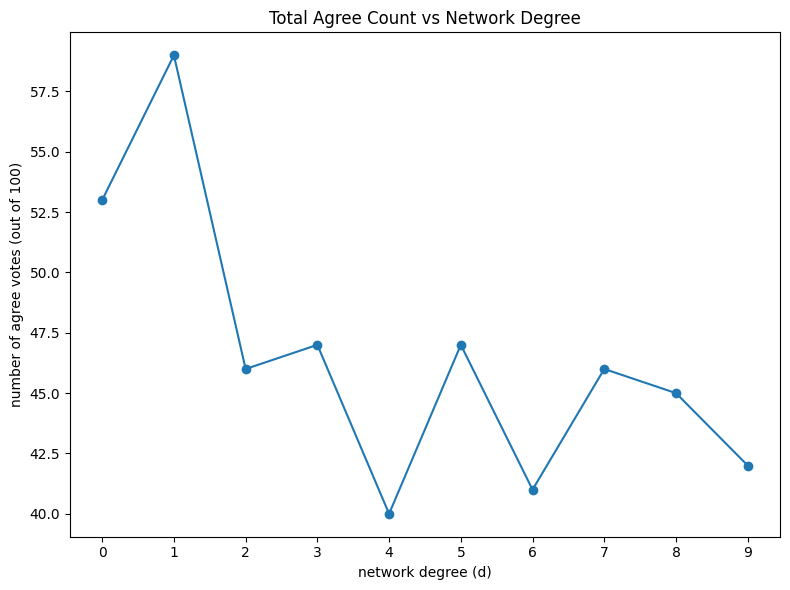

In [ ]:
import json, pandas as pd, matplotlib.pyplot as plt, numpy as np, pathlib, itertools, textwrap

data = json.loads(pathlib.Path('network_summary.json').read_text())

records = []
for block in data:
    d = block["degree"]
    for rec in block["votes"]:
        records.append({
            "degree": d,
            "model": rec["model"],
            "agree": rec["agree"],
            "disagree": rec["disagree"]
        })
df = pd.DataFrame(records)
df["total"] = df["agree"] + df["disagree"]

# Overall agree/disagree per degree
overall = (
    df.groupby("degree")[["agree","disagree"]]
      .sum()
      .reset_index()
      .sort_values("degree")
)

pivot = (
    df.pivot(index="degree", columns="model", values="agree")
      .sort_index()
)

table = pd.concat([overall[["agree","disagree"]], pivot], axis=1)
table.index.name = "degree"

table_path = 'network_degree_agree_table.csv'
table.to_csv(table_path)

plt.figure(figsize=(8,6))
plt.plot(overall["degree"], overall["agree"], marker="o")
plt.xticks(overall["degree"])
plt.ylabel("number of agree votes (out of 100)")
plt.xlabel("network degree (d)")
plt.title("Total Agree Count vs Network Degree")
plt.tight_layout()
plt.savefig("general.png", dpi=300)
plt.show()

In [ ]:
models = df["model"].unique()
models1 = ['groq_llama_4scout', 'openai_gpt4', 'google_gemini_25flash']
models2 = ['groq_qwen_qwq', 'ollama_gemma3', 'ollama_phi3']
models3 = ['ollama_llava', 'groq_mistral_saba']
models4 = ['groq_deepseek_r1', 'x_grok_3mini']

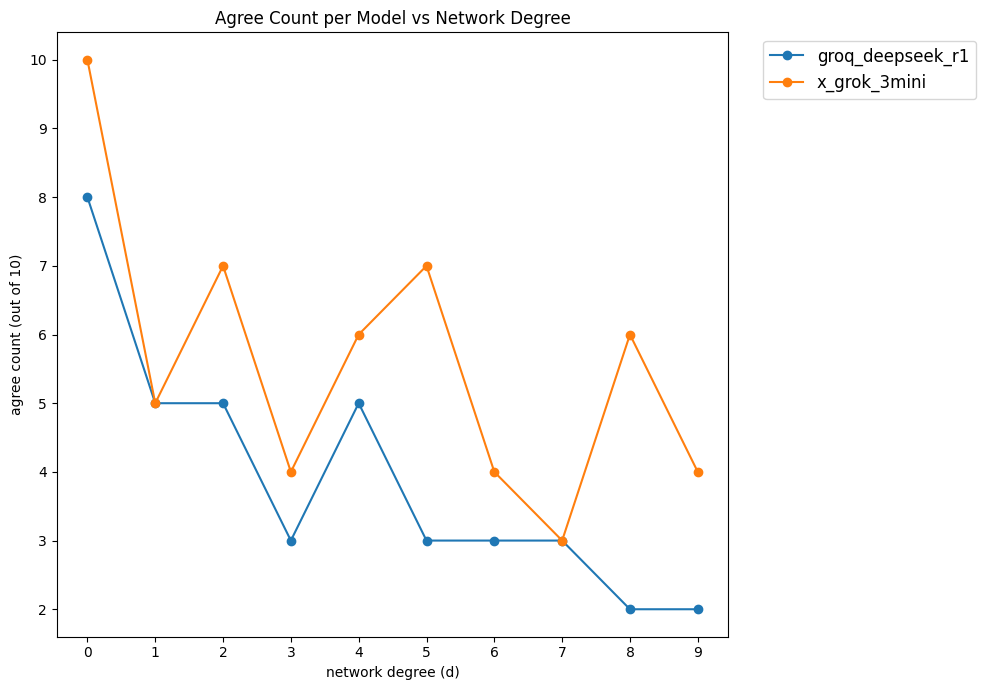

In [ ]:

fig, ax = plt.subplots(figsize=(10,7))
for m in models4:
    sub = df[df["model"] == m].sort_values("degree")
    ax.plot(sub["degree"], sub["agree"], marker="o", label=m)

ax.set_xlabel("network degree (d)")
ax.set_ylabel("agree count (out of 10)")
ax.set_title("Agree Count per Model vs Network Degree")
ax.set_xticks(sorted(df["degree"].unique()))
ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig("models_network_4", dpi=300)
plt.show()
